# Filter Sandbox

This notebook is used as a sandbox playground to see how the IIR and FIR filters corrrect different kinds of signals and to test their code before using it on the Cryoscope data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import savgol_filter, lfilter, gausspulse
from scipy.optimize import curve_fit

In [2]:
### Run this cell only if you're using "dark mode"

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png')

plt.rcParams.update({
    'figure.facecolor': '#383838',
    'figure.edgecolor': '#383838',
    'axes.facecolor':   '#383838',
    'axes.edgecolor':   '#DDE2F4',
    'axes.labelcolor':  '#DDE2F4',
    'xtick.color':      '#DDE2F4',
    'ytick.color':      '#DDE2F4',
    'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

In [36]:
def input_pulse(time):

    square_pulse = np.zeros(len(time))
    square_pulse[40:-80] = 1.0

    plt.plot(time * 1e3, square_pulse, label = 'Input Pulse')
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Input Pulse For System")
    #plt.grid(True)
    plt.legend()
    plt.show()

    """gauss_time = time - (time[-1] / 2)
    gaussian = gausspulse(gauss_time, fc = 20)

    plt.plot(time * 1e3, gaussian, label = "Input Pulse")
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Input Pulse For System")
    #plt.grid(True)
    plt.legend()
    plt.show()"""

    return square_pulse

In [ ]:
def high_pass_compensation(time, delta_t, input):

    tau = 1e-2 * 2.5
    fs = 1 / delta_t
    alpha = np.exp(-delta_t / tau)

    b0 = alpha
    b1 = -alpha
    a0 = 1
    a1 = -alpha

    feedforward_taps = np.array([b0, b1])
    feedback_taps = np.array([a0, a1])

    distorted_output = lfilter(feedforward_taps, feedback_taps, input)

    plt.plot(time * 1e3, distorted_output, label = "Distorted Output Signal (High-pass Compensation)", color = 'red')
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse For System After Distortion")
    #plt.grid(True)
    plt.legend()
    plt.show()

    return distorted_output, feedforward_taps, feedback_taps


In [129]:
def ringing(time, input):

    b0 = 1.0
    a0 = 1.0
    a1 = 0.25
    a2 = -a1

    print(a1, a2)

    feedforward_taps = np.array([b0])
    feedback_taps = np.array([a0, a1, a2])

    bmax = 2 - 2**-20
    highest_b = np.max(np.abs(feedforward_taps))

    amax = 1 - 2**-20

    if highest_b > bmax:
        feedforward_taps = 2 * feedforward_taps / highest_b

    if np.any(np.abs(feedback_taps)) > amax:
        feedback_taps[feedback_taps > amax] = amax
        feedback_taps[feedback_taps < -amax] = -amax

    distorted_output = lfilter(feedforward_taps, feedback_taps, input)

    plt.plot(time * 1e3, distorted_output, label = "Distorted Output Signal (Ringing)", color = 'red')
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse For System After Distortion")
    plt.ylim(0.7, 1.1)
    plt.xlim(35, 55)
    plt.legend()
    plt.show()

    

    return distorted_output, feedforward_taps, feedback_taps


In [122]:
def exp_system_response(time, delta_t, input):

    #A = np.random.uniform(-0.5,-0.05) # undershoot
    A = np.random.uniform(0.05,0.95) # overshoot
    tau = np.random.uniform(5*delta_t, 20*delta_t)

    alpha = np.exp(-delta_t / tau)
    b0 = 1 + A
    b1 = -(alpha + A)
    a0 = 1
    a1 = -alpha

    feedforward_taps = np.array([b0, b1])
    feedback_taps = np.array([a0, a1])

    distorted_output = lfilter(feedforward_taps, feedback_taps, input)

    """fs = 1 / delta_t
    alpha = 1 - np.exp(-1 / (fs * tau * (1 + A)))


    if A < 0:
        k = A / ((1 + A) * (1 - alpha))
    else:
        k = A / (1 + A - alpha)

    b0 = 1 - k + (k * alpha)
    b1 = -(1 - k) * (1 - alpha)
    a0 = 1
    a1 = -(1 - alpha)

    bmax = 2 - 2**-20
    highest_b = np.max(np.abs(feedforward_taps))

    amax = 1 - 2**-20

    if highest_b > bmax:
        feedforward_taps = 2 * feedforward_taps / highest_b

    if np.any(np.abs(feedback_taps)) > amax:
        feedback_taps[feedback_taps > amax] = amax
        feedback_taps[feedback_taps < -amax] = -amax"""

    plt.plot(time * 1e3, distorted_output, label = "Distorted Output Signal (Exponential)", color = 'red')
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse For System After Distortion")
    #plt.grid(True)
    plt.legend()
    plt.show()

    return distorted_output, feedforward_taps, feedback_taps

In [6]:
def filter_correction(input, distorted_output, time, Ma, Mb):

    x = distorted_output # information to input into filter tap finder
    y = input # the ideal signal to correct towards
    N = len(x)


    # build the convolution matrix
    S = np.zeros((N, Ma + Mb)) 
    for n in range(N):
        for mb in range(Mb): # starts from 0 and ends at Mb - 1
            i = n - mb
            if i >= 0:
                S[n, mb] = x[i]  
        for ma in range(Ma):
            i = n - (ma + 1)
            if i >= 0:
                S[n, Mb + ma] = -y[n - 1]


    h_inv = np.linalg.lstsq(S, y, rcond=None)[0]


    b = h_inv[:Mb]
    a = h_inv[Mb:]
    a = np.insert(a, 0, 1)

    x = input # now call x the actual input

    dpd_x = lfilter(b, a, x)

    plt.plot(time * 1e3, dpd_x, label = "Predistorted Input", color = 'orange')
    plt.legend()
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Input Pulse After Predistortion")
    #plt.grid(True)
    plt.show()

    return dpd_x


In [67]:
def full_correction(dpd_x, time, feedforward_taps, feedback_taps):

    full_output = lfilter(feedforward_taps, feedback_taps, dpd_x)

    plt.plot(time * 1e3, full_output, label = "Predistorted Output", color = 'lime')
    plt.legend()
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse After Predistortion and System Distortion")
    #plt.grid(True)
    plt.show()

In [72]:
def zoomed_in_comparison(dpd_x, dist_output, time, feedforward_taps, feedback_taps):

    full_output = lfilter(feedforward_taps, feedback_taps, dpd_x)

    plt.plot(time * 1e3, dist_output, label = "Distorted Output", color = "red")
    plt.plot(time * 1e3, full_output, label = "Predistorted Output", color = 'lime')
    plt.legend()
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u]")
    plt.title("Output Pulse With and Without Predistortion")
    #plt.ylim(0.7, 1.1)
    #plt.xlim(35, 55)
    plt.show()

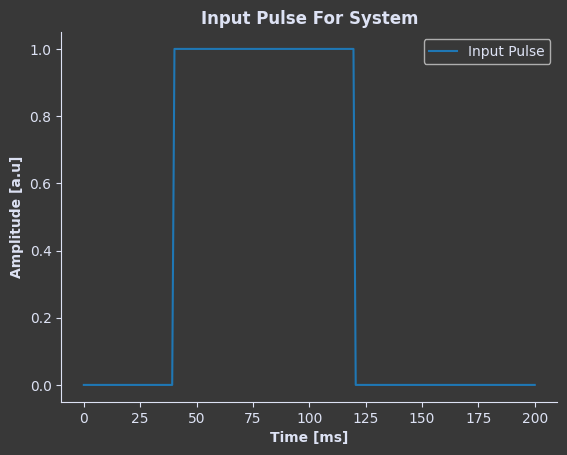

0.25 -0.25


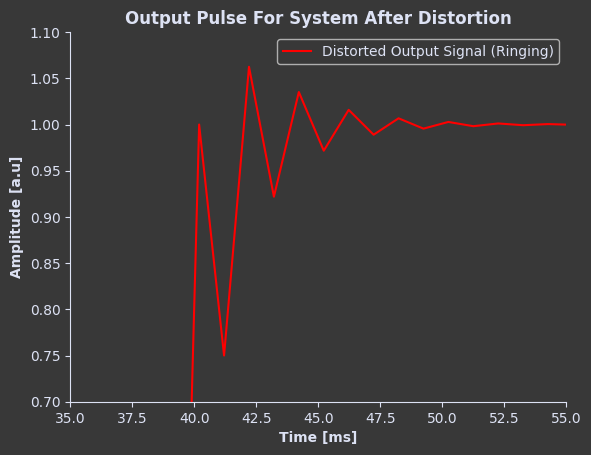

No. of feedbacks is 0 and No. of feedforwards is 3


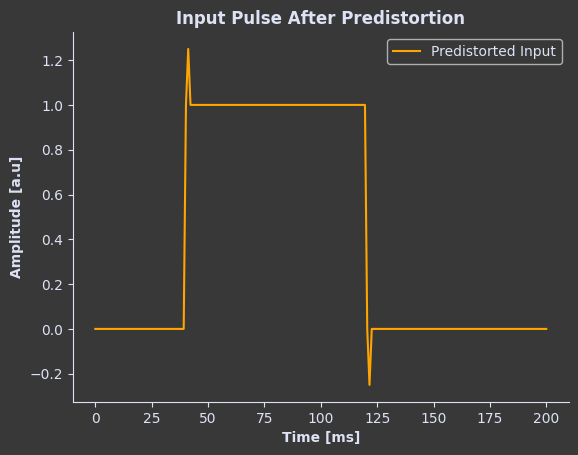

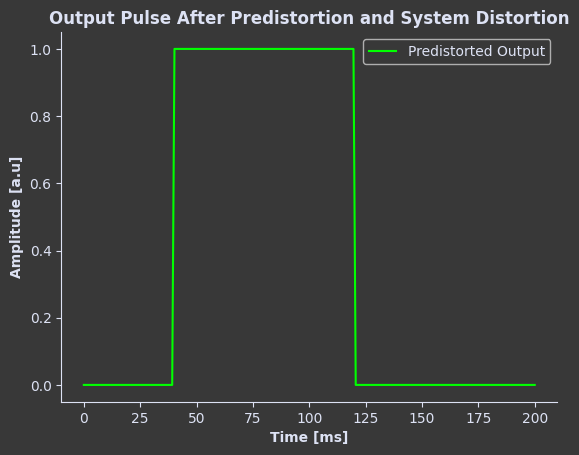

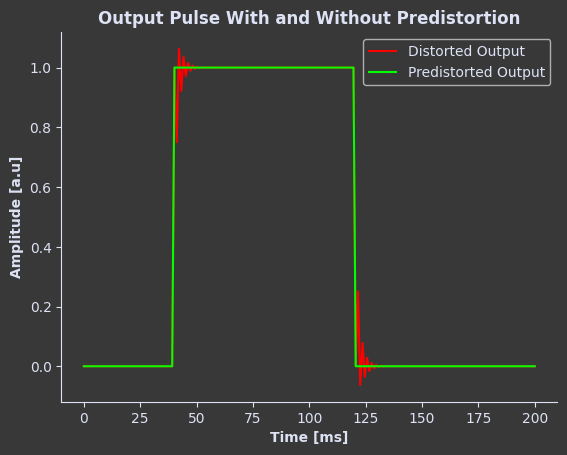

No. of feedbacks is 1 and No. of feedforwards is 3


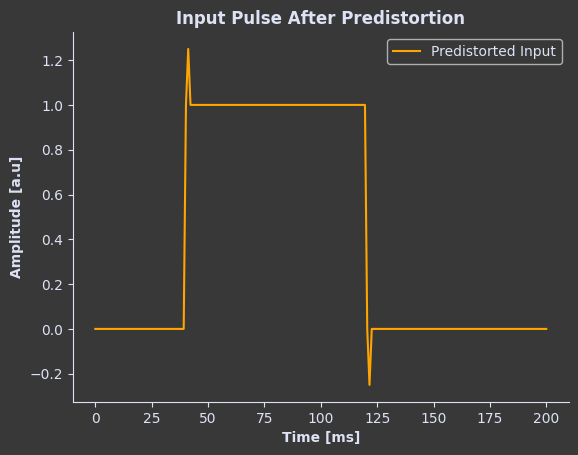

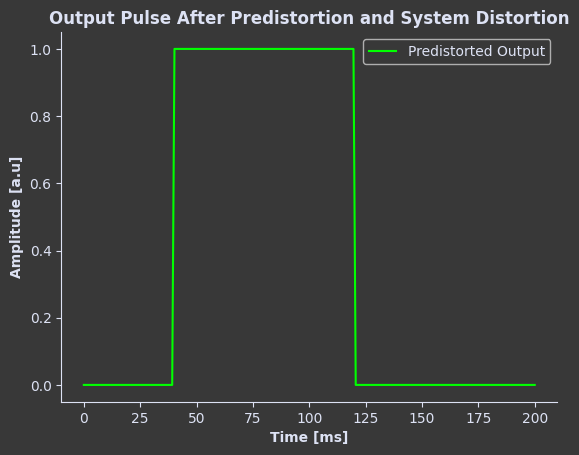

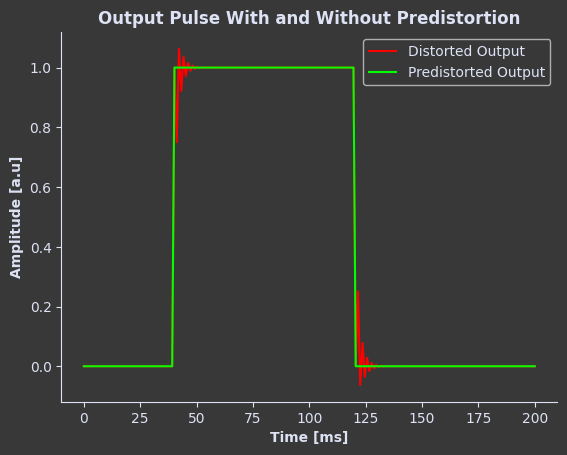

In [130]:
if __name__ == "__main__":

    ti = 0
    tf = 200e-3
    tshots = 200
    time = np.linspace(ti, tf, tshots)
    delta_t = time[1] - time[0]

    input = input_pulse(time)
    #dist_output, feedforward_taps, feedback_taps = exp_system_response(time, delta_t, input)
    dist_output, feedforward_taps, feedback_taps = ringing(time, input)
    #dist_output, feedforward_taps, feedback_taps = high_pass_compensation(time, delta_t, input)
    for Mb in [3]:
        for Ma in [0, 1]:
            print(f"No. of feedbacks is {Ma} and No. of feedforwards is {Mb}")
            dpd_x = filter_correction(input, dist_output, time, Ma, Mb)
            full_correction(dpd_x, time, feedforward_taps, feedback_taps)
            zoomed_in_comparison(dpd_x, dist_output, time, feedforward_taps, feedback_taps)
            


In [ ]:
def exponential_decay_fit(signal, time): # single iir filter

    target = np.ones_like(time)
    def step_exponential(t, A, tau, g):
        return target * (g * (1 + A * np.exp(-t / tau))) 


    # initial guesses
    g0 = 1.0  
    A0 = 0.5   
    tau0 = 20e-3              

    popt, _ = curve_fit(
        step_exponential,
        time,
        signal,
        p0 = [A0, tau0, g0]
    )

    A, tau, g = popt
    print("Fitted Exponential Parameters:")
    print(f"A = {A:.3f}. Expected range: [-1, 1)")
    print(f"tau_IIR = {tau*1e3:.3f} [ms]. Expected range: [6ns, 2ms]")
    print(f"g = {g:.3f}")

    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, step_exponential(time, *popt), label = 'Fitted Signal', alpha = 0.7, color = 'blue')
    plt.title('Exponential Decay Fit')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()

    return A, tau, g

In [ ]:
def exp_models(time):

    A = 0.1
    g = 1.0
    tau = 10e-3
    exp_decay = np.heaviside(time, 1.0) * g * (1 + A * np.exp(-time / tau))  # this is an overshoot
    #exp_decay += np.random.normal(0, 1e-3, size = exp_decay.shape) # potential for introducing stochastic noise
    exp_rise = np.heaviside(time, 1.0) * g * (1 - A * np.exp(-time/tau)) # this is an undershoot
    exp_rise += 0.01*np.sin(2*np.pi*time*10)
    #exp_rise += np.random.normal(0, 1e-3, size = exp_rise.shape)

    fig, (ax1, ax2) = plt.subplots(2, sharex = True)

    ax1.plot(time, exp_decay)
    ax1.set_title("Bias Tee Exponential-Overshoot Response")
    ax1.set(ylabel = 'Amplitude [a.u.]')
    ax1.grid(True)

    ax2.plot(time, exp_rise, 'tab:orange')
    ax2.set_title("Bias Tee Exponential-Undershoot Response")
    ax2.set(xlabel = 'Time [ms]', ylabel = 'Amplitude [a.u.]')
    ax2.grid(True)
    
    plt.show()

    return exp_decay, exp_rise

In [12]:
def IIR_filter_calc(A, tau, g, delta_t): # single iir filter

    fs = 1 / delta_t
    alpha = 1 - np.exp(-1 / (fs * tau * (1 + A)))

    #if not (0 <= alpha <= 1):
    #    raise ValueError(f"Unstable alpha: {alpha}")

    
    if A < 0:
        k = A / ((1 + A) * (1 - alpha))
    else:
        k = A / (1 + A - alpha)
    
    b0 = 1 - k + (k * alpha)
    b1 = -(1 - k) * (1 - alpha)
    a0 = 1
    a1 = -(1 - alpha)

    feedforward_taps = np.array([b0, b1])
    feedback_taps = np.array([a0, a1])

    bmax = 2 - 2**-20
    highest_b = np.max(np.abs(feedforward_taps))

    amax = 1 - 2**-20

    if highest_b > bmax:
        print("Correcting IIR filter feedforward coefficient...")
        feedforward_taps = 2 * feedforward_taps / highest_b

    if np.any(np.abs(feedback_taps)) > amax:
        print("Correcting IIR filter feedback coefficient...")
        feedback_taps[feedback_taps > amax] = amax
        feedback_taps[feedback_taps < -amax] = -amax
    

    print(f"Feedforward taps: {feedforward_taps}")
    print(f"Feedback taps: {feedback_taps}")

    return feedforward_taps, feedback_taps

In [13]:
def calc_IIR_correction(feedforward_taps, feedback_taps, signal, g): # single iir filter

    iir_correction = lfilter(feedforward_taps, feedback_taps, signal)
    iir_correction /= g  # compensate for gain

    return iir_correction

In [14]:
def FIR_filter_calc(signal, n_taps): 
    
    x = signal
    N = len(x)

    # desired output is the step function
    u = np.ones(N)
    
    # build convolution matrix
    X = np.zeros((N, n_taps))

    for n in range(N):
        for i in range(n_taps):
            if n - i >= 0:
                X[n, i] = x[n - i]

    # least-squares solution
    b, *_ = np.linalg.lstsq(X, u, rcond=None)

    return b

In [15]:
def FIR_filter_calc_cutoff(signal, n_taps, time): # tau_sweep back for cutoff

    if 2*n_taps > len(signal):
        raise ValueError("Number of taps is too large for the length of the signal and there cannot be a convolution matrix created. Please reduce n_taps.")

    cutoff = time[n_taps]
    mask = time >= cutoff # this is to ensure that the X convolution matrix has no zero entries

    x = signal[mask]
    N = len(x) + 1

    # desired output is the step function
    u = np.ones(N)

    # build convolution matrix
    X = np.zeros((N, n_taps))

    for n in range(N):
        for i in range(n_taps):
                X[n, i] = (signal[n - i + (n_taps - 1)])

    lambda_reg = 10e-4
    XtX = X.T @ X
    
    # least-squares solution
    b = np.linalg.lstsq(X, u, rcond = None)[0]
    #b = np.linalg.lstsq(XtX + lambda_reg * np.eye(n_taps), X.T @ u, rcond = None)[0]

    print("X:", X)
    print("b coefficients:", b)

    return b


In [16]:
def calc_FIR_correction(signal, fir_taps): 

    #fir_correction = np.convolve(signal, fir_taps, mode='full')[:len(signal)]
    fir_correction = lfilter(fir_taps, 1.0, signal)

    return fir_correction

In [ ]:
def general_IIR_filter(signal, Ma, Mb):

    N = len(signal) # number of time-step measurements, which is the no. of output samples to fit

    ideal = np.ones(N) # desired output is the step function

    # build the convolution matrix from the input signal and the output signal
    S = np.zeros((N, Ma + Mb)) 
    for n in range(N):
        for mb in range(Mb): # starts from 0 and ends at Mb - 1
            i = n - mb
            if i >= 0:
                S[n, mb] = signal[i]  
        for ma in range(Ma):
            i = n - ma
            if i >= 0:
                S[n, Mb + ma] = ideal[n - i]


    h_inv = np.linalg.lstsq(S, ideal, rcond=None)[0]


    b = h_inv[:Mb]
    a = h_inv[Mb:]
    a = np.insert(a, 0, 1)
    print(a)
    print(b)

    return a, b

In [17]:
def plot_IIR_results(time, signal, corrected_signal, title):

    plt.figure(figsize=(10, 6))
    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, corrected_signal, label = 'Corrected Signal', alpha = 0.7, color = 'cyan')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude (a.u)')
    plt.legend()
    plt.grid(True)
    #plt.xlim(0, 20)
    plt.show()

    """plt.figure(figsize=(10, 6))
    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, corrected_signal, label = 'Corrected Signal', alpha = 0.7, color = 'blue')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.xlim(50, 200)
    plt.show()"""

In [18]:
def plot_full_results(time, signal, iir_correction, fir_correction, title):

    plt.figure(figsize=(10, 6))
    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, iir_correction, label = 'IIR Corrected Signal', alpha = 0.7, color = 'cyan')
    plt.plot(time*1e3, fir_correction, label = 'IIR + FIR Corrected Signal', alpha = 0.7, color = 'lime')
    plt.title(title)
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude (a.u)')
    plt.legend()
    plt.grid(True)
    #plt.xlim(0, 20)
    plt.show()

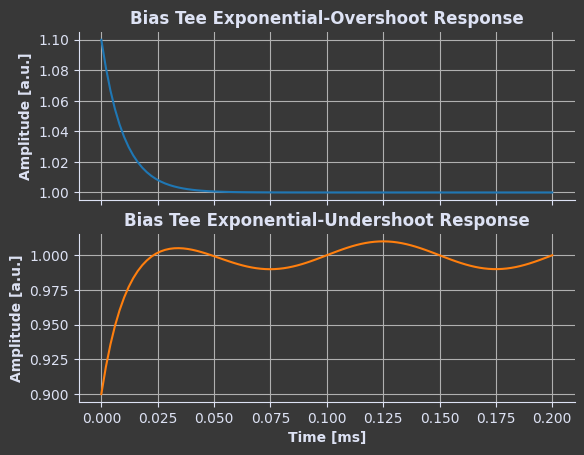

[1. 1.]
[ 2.43975562e-15 -1.22124533e-15]


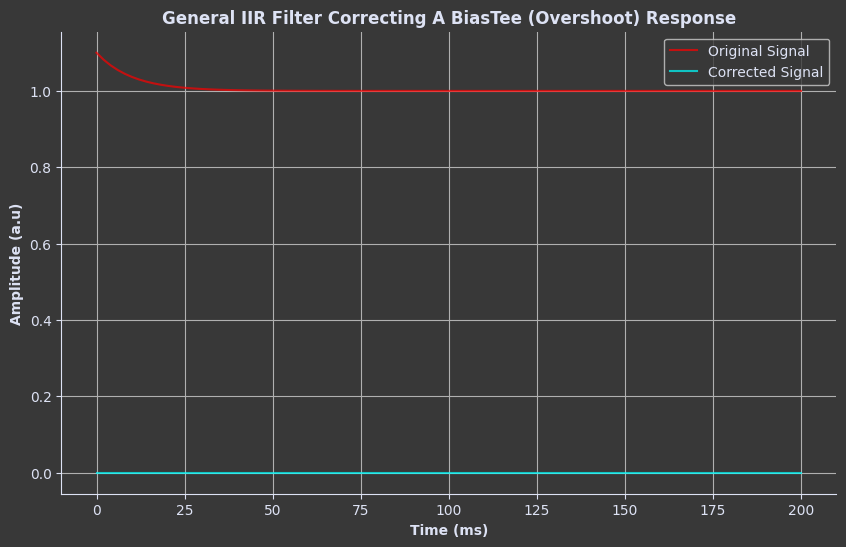

In [49]:
if __name__ == "__main__":
    nshots = 100
    ti = 0
    tf = 200e-3
    time = np.linspace(ti, tf, nshots)
    delta_t = time[1] - time[0]
    exp_overshoot, exp_undershoot = exp_models(time)

    """A, tau, g = exponential_decay_fit(exp_overshoot, time)
    feedforward_taps, feedback_taps = IIR_filter_calc(A, tau, g, delta_t)
    iir_correction = calc_IIR_correction(feedforward_taps, feedback_taps, exp_overshoot, g)
    plot_IIR_results(time, exp_overshoot, iir_correction, '1 IIR Filter Correcting A BiasTee (Overshoot) Response')

    A, tau, g = exponential_decay_fit(exp_undershoot, time)
    feedforward_taps, feedback_taps = IIR_filter_calc(A, tau, g, delta_t)
    iir_correction2 = calc_IIR_correction(feedforward_taps, feedback_taps, exp_undershoot, g)
    plot_IIR_results(time, exp_undershoot, iir_correction2, '1 IIR Filter Correcting A BiasTee (Undershoot) Response')"""

    a, b = general_IIR_filter(signal = exp_overshoot, Ma = 1, Mb = 2) # DO NOT include a0
    iir_correction_general = calc_IIR_correction(b, a, exp_overshoot, 1.0)
    plot_IIR_results(time, exp_overshoot, iir_correction_general, 'General IIR Filter Correcting A BiasTee (Overshoot) Response')


    """n_taps = 28
    b = FIR_filter_calc(iir_correction, n_taps)
    fir_correction = calc_FIR_correction(iir_correction, b)
    plot_full_results(time, exp_overshoot, iir_correction, fir_correction, '1 FIR Filter Correcting A BiasTee (Overshoot) Response')

    b = FIR_filter_calc(iir_correction2, n_taps)
    fir_correction = calc_FIR_correction(iir_correction2, b)
    plot_full_results(time, exp_undershoot, iir_correction2, fir_correction, f'IIR + FIR Filter with {n_taps} Taps Correcting A BiasTee (Undershoot) Response')"""



In [31]:
def multiple_exp_modes(time, modes, delta_t, type):

    
    if type == 'overshoot':
        As = np.random.uniform(0.05, 0.95 / modes, size = modes)
    elif type == 'undershoot':
        As = np.random.uniform(-0.95 / modes, -0.05, size = modes)
    else:
        As = np.random.uniform(-0.95 / modes, 0.95 / modes, size = modes)
        
    taus = np.random.uniform(5*delta_t, 50*delta_t, size = modes)
    g = 1.0

    exp_response = np.ones_like(time)
    for Ak, tauk in zip(As, taus):
        exp_response += Ak * np.exp(-time / tauk)
    
    exp_response = g * exp_response 
    exp_response += np.random.normal(0, 0.5e-3, size = exp_response.shape)

    plt.plot(time*1e3, exp_response)
    plt.title(f"{modes}-Mode Exponential Bias Tee Response")
    plt.xlabel("Time [ms]")
    plt.ylabel("Amplitude [a.u.]")
    plt.grid(True)
    plt.show()

    return exp_response

In [2]:
def multi_exponential_mode_fit(signal, time, n_iir):
    
    def exp_model(t, *params):
        A = params[:n_iir]
        tau = params[n_iir:-1]
        g = params[-1]

        s = np.ones_like(t)
        for Ak, tauk in zip(A, tau):
            s += Ak * np.exp(-t / tauk)

        return g * s

    # initial guesses
    A0 = np.full(n_iir, 0.5)
    tau0 = np.logspace(
        -4,
        -1, 
        n_iir
    )
    g0 = 1.0

    p0 = np.concatenate([A0, tau0, [g0]])

    lower_bounds = np.concatenate([
    np.full(n_iir, -0.99),      # A > -1
    np.full(n_iir, 10e-6),       # tau > 1us 
    [0.0]                       # g > 0
    ])

    upper_bounds = np.concatenate([
    np.full(n_iir, 0.99),        # A < 1
    np.full(n_iir, 1.0),        # tau < 1s
    [np.inf]
    ])

    popt, _ = curve_fit(
        exp_model,
        time,
        signal,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev = 20000000
    )

    A_list = popt[:n_iir]
    tau_list = popt[n_iir:-1]
    g = popt[-1]

    """print("Fitted Multi Exponential Rise Parameters:")
    for i, (A, tau) in enumerate(zip(A_list, tau_list)):
        print(f"  A{i+1} = {A:.3f} with expected range [-1, 1), \n tau{i+1} = {tau*1e3:.3f} [ms] with expected range (6ns, 3ms).")
    print(f"g = {g:.3f}")

    print("A length: ", len(A_list)); print("tau length: ", len(tau_list))"""

    # fitted forward response (diagnostic)
    fit_full = exp_model(time, *popt)

    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, fit_full, label = 'Multi-Fitted Signal', alpha = 0.7, color = 'blue')
    plt.title('Multiple-Exponential Model Fit')
    plt.xlabel('Time [ms]')
    plt.ylabel('Amplitude [a.u.]')
    plt.legend()
    plt.grid(True)
    plt.show()

    return A_list, tau_list, g


In [3]:
def IIR_filter_calc_multi(A_list, tau_list, delta_t): # each iir filter is dedicated to correcting an exponential mode

    fs = 1 / delta_t
    b_list = []
    a_list = []

    for A, tau in zip(A_list, tau_list):

        alpha = 1 - np.exp(-1 / (fs * tau * (1 + A))) 

        if A < 0:
            k = A / ((1 + A) * (1 - alpha))
        else:
            k = A / (1 + A - alpha)

        b = np.array([
            1 - k + (k * alpha),
            -(1 - k) * (1 - alpha)
        ])

        a = np.array([
            1,
            -(1 - alpha)
        ])

        b_list.extend(b)
        a_list.extend(a)

       
    b_tot = np.array(b_list)
    a_tot = np.array(a_list)

    bmax = 2 - 2**-16
    highest_b = np.max(np.abs(b_tot))

    amax = 1 - 2**-16

    if highest_b > bmax:
        #print("Correcting IIR filter feedforward coefficient...")
        b_tot = 2 * b_tot / highest_b

    if np.any(np.abs(a_tot)) > amax:
        #print("Correcting IIR filter feedback coefficient...")
        a_tot[a_tot > amax] = amax
        a_tot[a_tot < -amax] = -amax

    #print(f"Feedforward taps: {b_tot}")
    #print(f"Feedback taps: {a_tot}")

    return b_tot, a_tot


In [4]:
def calc_multi_IIR_correction(b_tot, a_tot, signal):

    iir_correction = signal.copy()

    for i in range(0, len(b_tot), 2):
        b = b_tot[i:i+2]
        a = a_tot[i:i+2]
        #print(f"Current b coeffs: {b} ")
        iir_correction = lfilter(b, a, iir_correction)

    iir_correction = np.divide(iir_correction, np.mean(iir_correction)) # normalise result

    return iir_correction

In [5]:
def residual_correction(signal, corrected_signal):

    mse = np.mean((signal - corrected_signal) ** 2)
    #print(f"Mean Squared Error of Correction: {mse:.6e}")
    
    return mse

In [6]:
def plot_multi_mode_results(time, signal, corrected_signal, n_iir, modes):

    plt.figure(figsize=(10, 6))
    plt.plot(time*1e3, signal, label = 'Original Signal', alpha = 0.7, color = 'red')
    plt.plot(time*1e3, corrected_signal, label = 'Corrected Signal', alpha = 0.7, color = 'cyan')
    plt.title(f"{n_iir} IIR Filter Correction to a {modes}-Mode Exponential Bias Tee Response")
    plt.xlabel('Time [ms]')
    plt.ylabel('Amplitude [a.u.]')
    plt.legend()
    plt.grid(True)
    #plt.xlim(0, 20)
    plt.show()

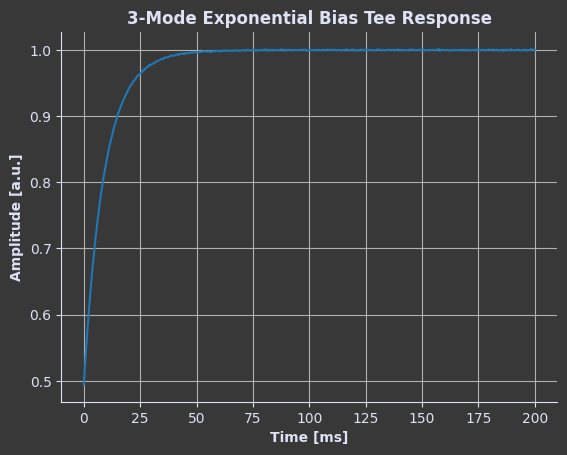

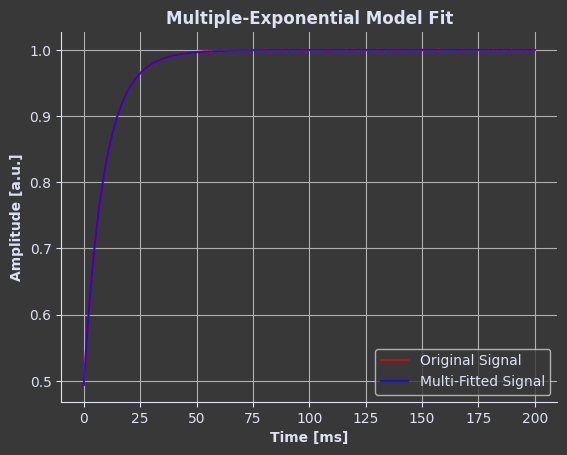

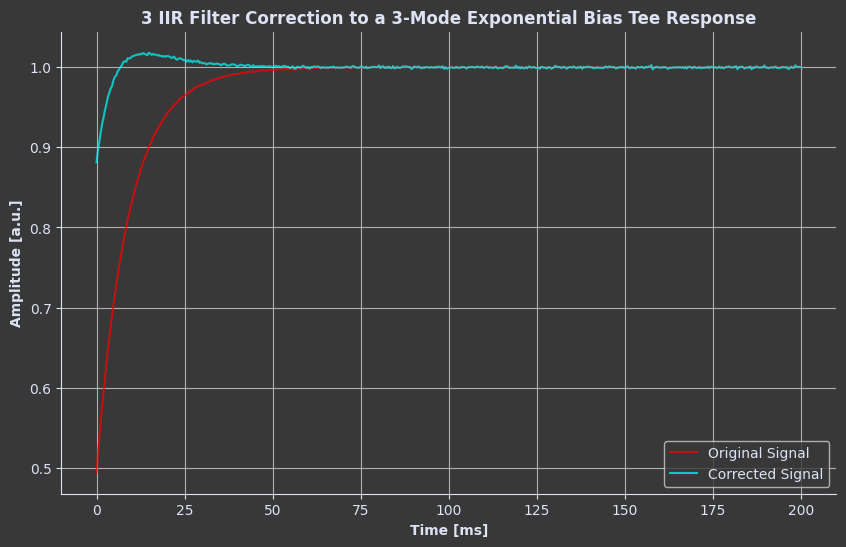

Number of IIR modes: 3, MSE: 5.108219e-03
Best correction achieved with 3 IIR modes.


In [33]:
if __name__ == "__main__":
    nshots = 500
    ti = 0
    tf = 200e-3
    time = np.linspace(ti, tf, nshots)
    delta_t = time[1] - time[0]
    modes = 3
    exp_response = multiple_exp_modes(time, modes, delta_t, type = 'undershoot')
    MSEs = []
    n_iir_list = [modes]
    for n_iir in n_iir_list:
        A_list, tau_list, g = multi_exponential_mode_fit(exp_response, time, n_iir)
        b_tot, a_tot = IIR_filter_calc_multi(A_list, tau_list, delta_t)
        iir_correction = calc_multi_IIR_correction(b_tot, a_tot, exp_response)
        plot_multi_mode_results(time, exp_response, iir_correction, n_iir, modes)
        mse = residual_correction(exp_response, iir_correction)
        print(f"Number of IIR modes: {n_iir}, MSE: {mse:.6e}")
        if not np.isnan(mse):
            MSEs.append(mse)
    best = np.argmin(MSEs)
    print(f"Best correction achieved with { n_iir_list[best] } IIR modes.")

Convolution Matrix X: [[1.00059883 0.         0.         ... 0.         0.         0.        ]
 [1.00354776 1.00059883 0.         ... 0.         0.         0.        ]
 [1.00697528 1.00354776 1.00059883 ... 0.         0.         0.        ]
 ...
 [0.99418104 0.99363722 0.99059353 ... 0.99791326 1.00136836 1.00523012]
 [0.99654933 0.99418104 0.99363722 ... 0.99435422 0.99791326 1.00136836]
 [1.0003569  0.99654933 0.99418104 ... 0.99330393 0.99435422 0.99791326]]
FIR filter coefficients: [ 9.99253115e-01 -3.06577523e-03 -3.57668229e-03 -1.53607956e-03
 -3.44881093e-05 -4.63107318e-03  3.27691727e-03  2.30668545e-03
 -5.73197281e-04  6.77292878e-03  3.08650990e-03  3.28285746e-03
  3.06726629e-03  1.71559770e-03  3.16612248e-03 -5.27983577e-04
 -3.51723298e-04 -4.20778302e-03 -1.39965995e-03 -3.82445777e-03
 -2.14675162e-03 -3.50883941e-03 -2.90401172e-03 -3.17769794e-03
 -1.15823245e-04  3.04132186e-05  1.37141411e-04  2.11784141e-03
  2.61043472e-03  3.03412521e-03  1.64858843e-03  3.28

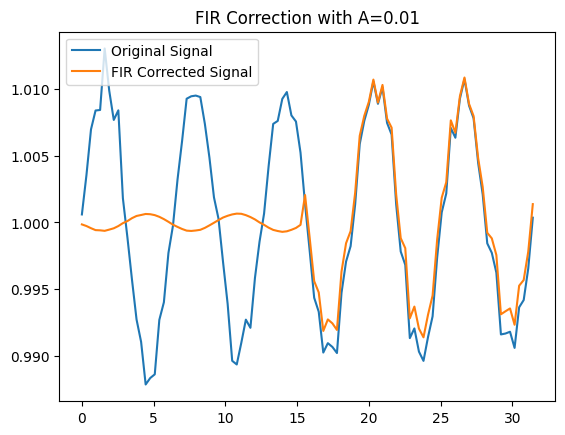

Convolution Matrix X: [[1.00134387 0.         0.         ... 0.         0.         0.        ]
 [1.04850089 1.00134387 0.         ... 0.         0.         0.        ]
 [1.05667647 1.04850089 1.00134387 ... 0.         0.         0.        ]
 ...
 [0.9411628  0.93165405 0.90471052 ... 0.97336203 1.02206257 1.05461481]
 [0.97310295 0.9411628  0.93165405 ... 0.96101296 0.97336203 1.02206257]
 [1.00286134 0.97310295 0.9411628  ... 0.91873971 0.96101296 0.97336203]]
FIR filter coefficients: [ 9.88435055e-01 -4.34787905e-02 -9.16568866e-03 -2.37074542e-02
 -1.20191793e-02 -7.04754552e-03  1.20706684e-02  2.28826961e-02
  9.79875099e-03  3.45958199e-02  3.14250189e-02  2.69759517e-02
  2.98060595e-02  1.97917109e-02  1.87162347e-02 -1.21071870e-02
  5.85190768e-03 -3.32659768e-02 -1.11500634e-02 -2.68567719e-02
 -2.92982592e-02 -2.66743841e-02 -3.32506237e-02 -1.93402998e-02
  1.30976695e-02 -2.55605345e-02  2.86663091e-02  1.23834733e-02
  3.94699304e-02  2.29454010e-03  5.13281346e-02 -1.51

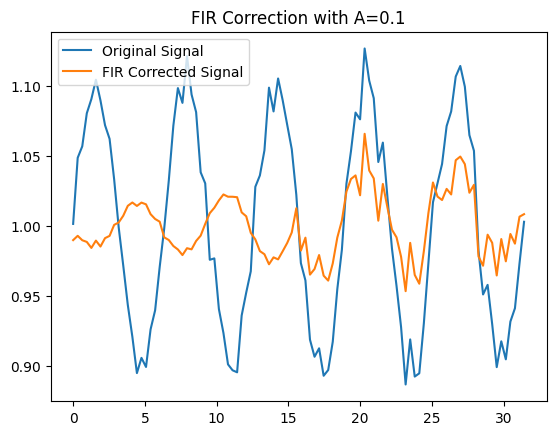

Convolution Matrix X: [[1.00401916 0.         0.         ... 0.         0.         0.        ]
 [1.10363538 1.00401916 0.         ... 0.         0.         0.        ]
 [1.13907218 1.10363538 1.00401916 ... 0.         0.         0.        ]
 ...
 [0.86020418 0.83622054 0.74127576 ... 0.97035036 0.96099952 1.13294458]
 [0.91823686 0.86020418 0.83622054 ... 0.88761531 0.97035036 0.96099952]
 [0.99321987 0.91823686 0.86020418 ... 0.8433097  0.88761531 0.97035036]]
FIR filter coefficients: [ 9.62124771e-01 -5.94779349e-02 -4.40751270e-02 -7.13612405e-02
  6.06167461e-03 -6.74609936e-03  5.07686861e-02 -8.71178025e-03
  5.56148148e-02  5.98183007e-02  7.93974476e-02  3.40654968e-02
  3.86196320e-02 -2.85079502e-03  5.40703333e-02  3.36708771e-04
 -2.42571466e-02 -1.57274080e-02 -1.95363902e-02 -7.41003271e-02
 -3.40095134e-02 -7.88086526e-02 -5.45160082e-03  1.23450047e-02
  2.14789122e-02 -6.65896377e-04  7.33299842e-03  1.49091823e-02
  5.15769621e-03  6.01636855e-02 -1.44232773e-02  2.81

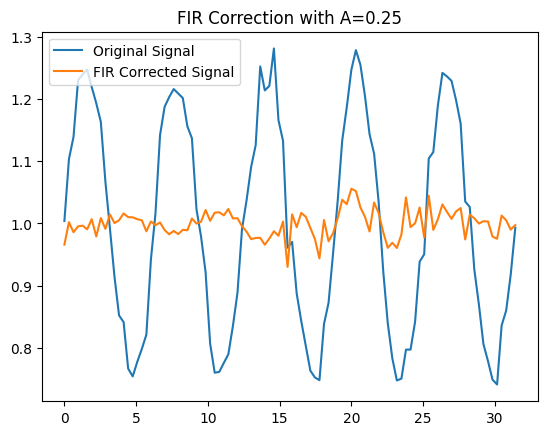

Convolution Matrix X: [[0.90476943 0.         0.         ... 0.         0.         0.        ]
 [1.04302955 0.90476943 0.         ... 0.         0.         0.        ]
 [1.3190602  1.04302955 0.90476943 ... 0.         0.         0.        ]
 ...
 [0.70711794 0.64268594 0.58356389 ... 0.80920991 1.04877945 1.23542173]
 [0.91942289 0.70711794 0.64268594 ... 0.83030737 0.80920991 1.04877945]
 [0.89403942 0.91942289 0.70711794 ... 0.65568368 0.83030737 0.80920991]]
FIR filter coefficients: [ 0.91584351 -0.06220731 -0.12582606 -0.05304184 -0.06679966  0.01398441
  0.08619935  0.01269356  0.18891285  0.0547334   0.01413752  0.13583336
 -0.01710104  0.02533276  0.05771255 -0.03903227 -0.05748004  0.01190606
 -0.00930824 -0.06331644 -0.05558757 -0.01874309  0.0019157  -0.03414535
 -0.02573718  0.04095086  0.02596255 -0.00802432 -0.00397499 -0.0193794
  0.13408605 -0.06226629 -0.0109864   0.07411507  0.01273938 -0.14523946
  0.07836829  0.0394028  -0.00711133  0.03837567 -0.05671815 -0.00669002

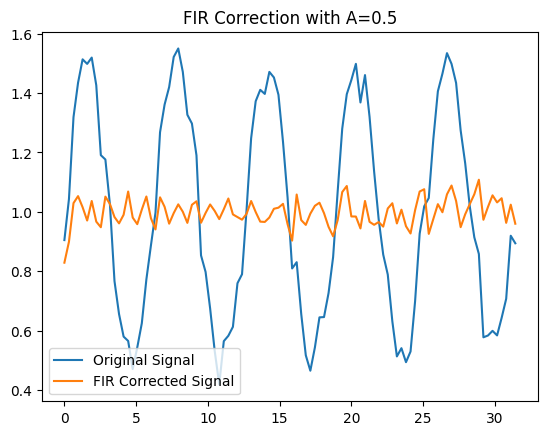

Convolution Matrix X: [[1.02115227 0.         0.         ... 0.         0.         0.        ]
 [1.25090671 1.02115227 0.         ... 0.         0.         0.        ]
 [1.51339152 1.25090671 1.02115227 ... 0.         0.         0.        ]
 ...
 [0.64978947 0.45711196 0.34654553 ... 0.9002326  1.19785075 1.3190853 ]
 [0.7090022  0.64978947 0.45711196 ... 0.63436333 0.9002326  1.19785075]
 [0.98791118 0.7090022  0.64978947 ... 0.42403151 0.63436333 0.9002326 ]]
FIR filter coefficients: [ 0.77126992  0.00917562 -0.21444564  0.02520448 -0.05986478 -0.01500147
  0.10015077  0.0798701   0.12719056  0.09876415  0.00901401 -0.00207734
  0.1519877   0.04173293 -0.05269338  0.07587699 -0.06621861 -0.03783877
  0.04007462 -0.10383008  0.03273005 -0.05140526  0.01611531 -0.00617362
 -0.01016328 -0.02917166 -0.07359525  0.07918495  0.06135184 -0.08433088
  0.17798144 -0.09128435 -0.10555673  0.07305974  0.02560429  0.01021746
 -0.02837966  0.05228686 -0.07931708 -0.05354225  0.07703911  0.0348841

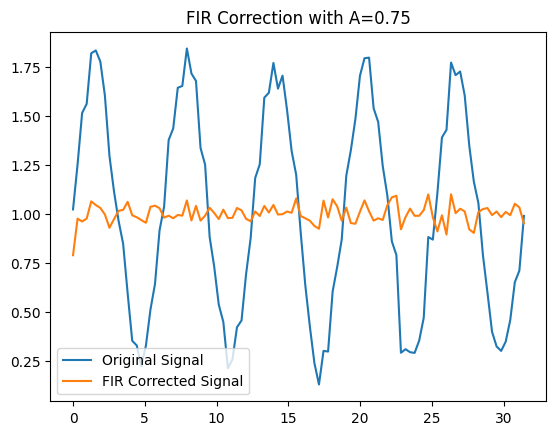

In [ ]:
# investigating how the FIR filter corrects for different amplitudes

t = np.linspace(0, 10*np.pi, 100)
for A in [0.01, 0.1, 0.25, 0.5, 0.75]:
    x = 1 + A * np.sin(t) + (A / 10) * np.random.normal(size=100) 

    N = len(x)

    # desired output is the step function
    u = np.ones(N)
    n_taps = 50

    # build convolution matrix
    X = np.zeros((N, n_taps))

    for n in range(N):
        for i in range(n_taps):
            if n - i >= 0:
                X[n, i] = x[n - i]

    print(f"Convolution Matrix X: {X}")

    b, *_ = np.linalg.lstsq(X, u, rcond=None)

    fir_correction = np.matmul(X, b)

    print(f"FIR filter coefficients: {b}")

    plt.plot(t, x, label='Original Signal')
    plt.plot(t, fir_correction, label='FIR Corrected Signal')
    plt.legend()
    plt.title(f'FIR Correction with A={A}')
    plt.show()
